In [6]:
#CNN SD implementation for NG - CIP dataset
import numpy as np
import pandas as pd
from Bio import SeqIO
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torchinfo import summary
import os

In [7]:
GENOME_SIZE = 2171755 #NG

In [8]:
# load pheno df
pheno_df = pd.read_csv("../data/NeisseriaGono-CIP.tsv", sep="\t")
print(pheno_df.head())

              id drug_agent pheno_eucast
1  ECDC_BE18_497        CIP            S
2    ERR11171225        CIP            R
3    ERR11171451        CIP            R
4    ERR11171618        CIP            R
5    ERR11171778        CIP            S


In [9]:
pheno_df["pheno_eucast"].value_counts()

R    2605
S    2232
Name: pheno_eucast, dtype: int64

In [10]:
import os
import torch
import pandas as pd

# -----------------------------
# Load tensor + sample order
# -----------------------------
X = torch.load("X_tensor.pt")   # shape: (N, 6, L)
sample_names = pd.read_csv("sample_names.csv").iloc[:, 0].tolist()

# sample_names are like: ERR11171225_output.vcf
sample_ids = [s.split("_")[0] for s in sample_names]

print("First 5 sample names:", sample_names[:5])
print("First 5 sample IDs:", sample_ids[:5])

# -----------------------------
# Keep only phenotype rows with matching VCF/tensor samples
# -----------------------------
pheno_df = pheno_df.copy()
pheno_df = pheno_df[pheno_df["id"].isin(sample_ids)].copy()

# encode phenotype: R = 1, S = 0
pheno_df["pheno_encoded"] = pheno_df["pheno_eucast"].map({"R": 1, "S": 0})

# build mapping from accession -> label
label_map = dict(zip(pheno_df["id"], pheno_df["pheno_encoded"]))

# check missing labels
missing = [sid for sid in sample_ids if sid not in label_map]
if missing:
    raise ValueError(f"Missing phenotype labels for {len(missing)} samples: {missing[:10]}")

# build y in EXACT same order as X
y = torch.tensor([label_map[sid] for sid in sample_ids], dtype=torch.float32)

# -----------------------------
# Sanity checks
# -----------------------------
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

assert X.shape[0] == len(y), f"Mismatch: X has {X.shape[0]} samples but y has {len(y)} labels"
assert X.ndim == 3, f"Expected X to have shape (N, 6, L), got {X.shape}"
assert X.shape[1] == 6, f"Expected 6 channels, got {X.shape[1]}"

# X is already a tensor from torch.load
X = X.float()

print("Torch X shape:", X.shape)
print("Torch y shape:", y.shape)

# -----------------------------
# Move to device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = X.to(device)
y = y.to(device)

print("X device:", X.device)
print("y device:", y.device)

pheno_ordered = pheno_df.set_index("id").loc[sample_ids].reset_index()
print(pheno_ordered[["id", "pheno_eucast", "pheno_encoded"]].head())

First 5 sample names: ['ERR11171451_output.vcf', 'ERR11171778_output.vcf', 'ERR11171780_output.vcf', 'ERR11171782_output.vcf', 'ERR11171784_output.vcf']
First 5 sample IDs: ['ERR11171451', 'ERR11171778', 'ERR11171780', 'ERR11171782', 'ERR11171784']
Shape of X: torch.Size([200, 6, 2171755])
Shape of y: torch.Size([200])
Torch X shape: torch.Size([200, 6, 2171755])
Torch y shape: torch.Size([200])
X device: cuda:0
y device: cuda:0
            id pheno_eucast  pheno_encoded
0  ERR11171451            R              1
1  ERR11171778            S              0
2  ERR11171780            S              0
3  ERR11171782            S              0
4  ERR11171784            S              0


In [11]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.conv1 = nn.Conv1d(6, 16, kernel_size=12, stride=4)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=12, stride=4)
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)

        self.conv3 = nn.Conv1d(32, 32, kernel_size=3, stride=2)
        self.pool2 = nn.MaxPool1d(kernel_size=4, stride=4)

        self.global_pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(32, 64)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool1(x)
        x = torch.relu(self.conv3(x))
        x = self.pool2(x)
        x = self.global_pool(x).squeeze(-1)
        x = torch.relu(self.fc1(x))
        x = self.out(x)
        return x

In [12]:
#instantiate model
model = CNN(num_classes=1)
model = model.to(device="cuda" if torch.cuda.is_available() else "cpu")
summary(model)

Layer (type:depth-idx)                   Param #
CNN                                      --
├─Conv1d: 1-1                            1,168
├─Conv1d: 1-2                            6,176
├─MaxPool1d: 1-3                         --
├─Conv1d: 1-4                            3,104
├─MaxPool1d: 1-5                         --
├─AdaptiveMaxPool1d: 1-6                 --
├─Linear: 1-7                            2,112
├─Linear: 1-8                            65
Total params: 12,625
Trainable params: 12,625
Non-trainable params: 0

In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import torch

# -----------------------------
# Keep full tensors on CPU
# -----------------------------
X_cpu = X.detach().cpu().float()
y_cpu = y.detach().cpu().float()

# indices-based split
indices = np.arange(len(y_cpu))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_cpu.numpy()
)

# apply split
X_train = X_cpu[train_idx]
X_test  = X_cpu[test_idx]
y_train = y_cpu[train_idx]
y_test  = y_cpu[test_idx]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# DataLoaders
# IMPORTANT: keep X on CPU; move mini-batches to GPU in training loop
# -----------------------------
batch_size = 1

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

Train shapes: torch.Size([160, 6, 2171755]) torch.Size([160])
Test shapes: torch.Size([40, 6, 2171755]) torch.Size([40])
Using device: cuda


In [15]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
model = model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(xb).squeeze(1)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            running_correct += (preds == yb).sum().item()
            total += yb.size(0)
            running_loss += loss.item() * yb.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch 01 | Train Loss: 0.6914 | Train Acc: 0.5437
Epoch 02 | Train Loss: 0.6592 | Train Acc: 0.6188
Epoch 03 | Train Loss: 0.5473 | Train Acc: 0.7937
Epoch 04 | Train Loss: 0.5036 | Train Acc: 0.7875
Epoch 05 | Train Loss: 0.4686 | Train Acc: 0.8125
Epoch 06 | Train Loss: 0.3911 | Train Acc: 0.8375
Epoch 07 | Train Loss: 0.3325 | Train Acc: 0.8750
Epoch 08 | Train Loss: 0.2614 | Train Acc: 0.9125
Epoch 09 | Train Loss: 0.2232 | Train Acc: 0.9375
Epoch 10 | Train Loss: 0.1802 | Train Acc: 0.9375
Epoch 11 | Train Loss: 0.1259 | Train Acc: 0.9500
Epoch 12 | Train Loss: 0.1094 | Train Acc: 0.9563
Epoch 13 | Train Loss: 0.0674 | Train Acc: 0.9812
Epoch 14 | Train Loss: 0.1074 | Train Acc: 0.9500
Epoch 15 | Train Loss: 0.0740 | Train Acc: 0.9750
Epoch 16 | Train Loss: 0.0292 | Train Acc: 0.9938
Epoch 17 | Train Loss: 0.0142 | Train Acc: 1.0000
Epoch 18 | Train Loss: 0.0052 | Train Acc: 1.0000
Epoch 19 | Train Loss: 0.0041 | Train Acc: 1.0000
Epoch 20 | Train Loss: 0.0041 | Train Acc: 1.0000


In [16]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": num_epochs,
}, "cnn_model.pt")

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score
import torch

model.eval()

all_probs = []
all_y = []

with torch.no_grad():
    for xb, yb in test_loader:   # ← this IS y_test
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu())
        all_y.append(yb.detach().cpu())

# concatenate all batches
probs = torch.cat(all_probs)
y_true = torch.cat(all_y)

# convert to numpy
probs_np = probs.numpy()
y_np = y_true.numpy()

# predictions
preds_np = (probs_np >= 0.5).astype(int)

# metrics
acc = accuracy_score(y_np, preds_np)
precision = precision_score(y_np, preds_np, pos_label=1, zero_division=0)
recall = recall_score(y_np, preds_np, pos_label=1, zero_division=0)

try:
    auroc = roc_auc_score(y_np, probs_np)
except ValueError:
    auroc = float("nan")

try:
    auprc = average_precision_score(y_np, probs_np)
except ValueError:
    auprc = float("nan")

print(f"N test samples: {len(y_np)}")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision (R) : {precision:.4f}")
print(f"Recall (R)    : {recall:.4f}")
print(f"AUROC         : {auroc:.4f}")
print(f"AUPRC         : {auprc:.4f}")

N test samples: 40
Accuracy      : 0.9500
Precision (R) : 0.9545
Recall (R)    : 0.9545
AUROC         : 0.9747
AUPRC         : 0.9748


Matches y_test: True


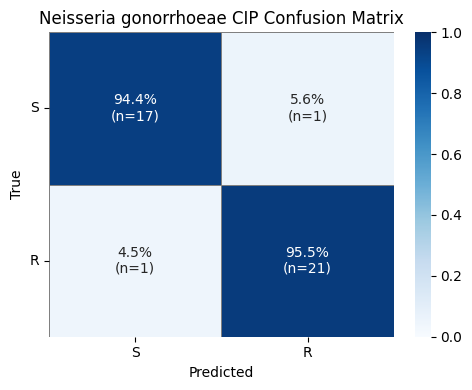

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_preds.append(preds.cpu())
        all_true.append(yb.cpu())

# concatenate
y_true = torch.cat(all_true).numpy()
y_pred = torch.cat(all_preds).numpy()

# sanity check
print("Matches y_test:", np.all(y_true == y_test.cpu().numpy()))

#cm
cm = confusion_matrix(y_true, y_pred)
labels = ["S", "R"]

# safe normalization
row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = np.divide(cm, row_sums, where=row_sums != 0)

# annotations
annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm_percent[i, j] * 100 if row_sums[i] > 0 else 0
        annot[i, j] = f"{pct:.1f}%\n(n={cm[i, j]})"

cm_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=True,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Neisseria gonorrhoeae CIP Confusion Matrix")
ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(labels, rotation=0)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()